# 一、前言

主要任务就是手写 VAE on MNIST 的代码并验证输出结果和Jaan Altosaar, Tutorial on Variational Autoencoders、d2l 附录概率论（高斯分布、KL 散度）这2个配套理论学习

# 二、理论

## 1.aan Altosaar《Tutorial - What is a variational autoencoder?》

定位：用神经网络 + 概率图模型双视角讲 VAE，弥合两个领域的语言鸿沟。

视角 A（神经网络）：
- 把编码器和译码器都分别看作一个神经网络
- encoder qθ(z|x)：784 维 → bottleneck z（随机变量，输出高斯参数 μ、σ）；
- decoder pφ(x|z)：z → 数据分布参数（MNIST 用 Bernoulli，逐像素 0/1）；
- 单样本损失：lᵢ(θ,φ) = −E_{q}[log pφ(xᵢ|z)] + KL(qθ(z|xᵢ) ‖ p(z))，p(z)=N(0,1)；
- 第二项的作用（最通俗的解释）：防止 encoder 作弊——不给正则，encoder 会把每个样本塞进互不重叠的区- 域，同类数字（不同人写的 2）表示会相距很远；正则强制 z 空间有结构。

视角 B（概率图模型）：
- 生成过程：z ~ p(z)，x ~ p(x|z)；联合 p(x,z)=p(x|z)p(z)；
- 后验 p(z|x) 的分母 p(x)=∫p(x|z)p(z)dz 是指数时间积分，不可算 → 变分推断；
- 用 q(z|x) 逼近 p(z|x)，但 KL(qλ‖p(z|x)) 里含着 log p(x)，还是不可算；
- 出路：ELBO(λ) = E_q[log p(x,z)] − E_q[log q]；由 Jensen 不等式 log p(x) = ELBO + KL ≥ ELBO；
- 于是：最小化 KL = 最大化 ELBO；单样本 ELBOᵢ = E_q[log p(xᵢ|z)] − KL(qλ(z|xᵢ)‖p(z)) = −lᵢ（和我们损失差个负号）；
- 用推理网络（encoder）参数化 q、生成网络（decoder）参数化 pφ → 这就成了 VAE；同时优化两组参数 = 变分 EM。
- 重参数化 trick（文末 footnote）：z = μ + σ⊙ε，ε ~ N(0,1)——把随机性全部推到 ε，采样变成确定性函数，梯度能穿过采样层回传。

扩展概念：mean-field vs amortized inference（每个数据点独立参数 λᵢ vs 共享参数的推理网络——VAE 属于后者）；MNIST 用 Bernoulli 其实不精确（像素是连续的），改进是 continuous Bernoulli（文末引用）。

先验 p(z)：在没有任何图像输入时，我们默认隐编码 z 应该围绕原点，服从单位高斯分布，像是事前对隐空间的预设，它大概长什么样子<br>
后验 qλ(z|x):其实这里是近似后验，因为真实后验是看到了一张图片，然后想直接反推这张图片最有可能来自隐空间的哪个位置 z,但 p(x) 非常难算，继而变为近似后验；近似后验就是编码器 q(z|x) ，逼着编码器输出的隐分布，不要偏离预先设定的先验 p(z) 标准正态分布太远

对应代码：Cell 5 的 recon+kl 就是 −ELBO；Cell 3 的 mu+eps*std 就是重参数化。

## 2.d2l 概率与信息论

2.6 概率 
- 基本概率论：抽样与分布、大数定律（频率→概率收敛）、Kolmogorov 公理、随机变量（离散 vs 连续——密度概念）；
- 多随机变量：联合概率、条件概率、贝叶斯定理 P(A|B)=P(B|A)P(A)/P(B)、边际化 P(B)=Σ_A P(A,B)、独立性与条件独立；
- 期望 E[X]=Σx·P(X=x)、方差 Var[X]=E[(X−E[X])²]；
- 有完整的 HIV 检测贝叶斯应用例子（两次检测把后验从 13% 提到 83%）——练贝叶斯手感的好例子；
- 注意：本节示例全是离散分布；连续分布（高斯）在 v1 附录"随机变量"节（2.6 正文自己这么引用的）。

KL 散度（信息论主题，标准公式 + Kingma 附录 B 闭式解）：
- 定义：KL(P‖Q) = Σ_x P(x)·log(P(x)/Q(x))（离散；连续为积分形式）；
- 性质：KL≥0，等号当且仅当 P=Q；不对称，KL(P‖Q) ≠ KL(Q‖P)，所以不是距离；
- 高斯-高斯闭式解：KL(N(μ₁,σ₁²)‖N(μ₂,σ₂²)) = log(σ₂/σ₁) + (σ₁²+(μ₁−μ₂)²)/(2σ₂²) − ½；
- 代入先验 N(0,1)（μ₂=0, σ₂=1）：½(σ²+μ²−1−lnσ²)；令 logvar=lnσ² 即得代码那一行：kl = -0.5*torch.sum(1 + logvar - mu**2 - logvar.exp())；

# 三、代码

## 1.导入 + 超参 + 随机种子

In [1]:
import torch
import torch.nn as nn      # 神经网络模块，用来搭建网络层（Linear、Conv2d 等）
import torch.nn.functional as F     # 函数式接口，激活函数、损失函数，如 F.relu、F.mse_loss
from torch.utils.data import DataLoader     # 批量加载数据集，负责分批、打乱、多线程读取数据
from torchvision import datasets, transforms    # 内置数据集，MNIST、CIFAR‑10 等；图像预处理（归一化、转张量）
import matplotlib.pyplot as plt
torch.manual_seed(42)          # 固定种子：保证每次运行结果一致，调参才能对照
BATCH_SIZE = 128               # 批次大小，一次迭代送入 128 张图片训练
LATENT_DIM = 20                # Kingma 论文在 MNIST 上的标准设置（2~40 都行）
LR = 1e-3     # Adam 优化器常用初始学习率 0.001
EPOCHS = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


LATENT_DIM = 20<br>
**隐变量 z 的维度**，VAE 编码器输出均值$\mu$、方差$\sigma$都是长度 20 的向量；原始 VAE 论文 MNIST 实验就是取 20 维隐空间

## 2.数据加载

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)),
])
train_set = datasets.MNIST(root = './data', train = True, download = True, transform = transform)
test_set = datasets.MNIST(root = './data', train = False, download = True, transform = transform)
train_loader = DataLoader(train_set, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_set, batch_size = BATCH_SIZE, shuffle = False)
x, y = next(iter(train_loader))
print(x.shape, y.shape, '像素范围:', x.min().item(), '~', x.max().item())

torch.Size([128, 784]) torch.Size([128]) 像素范围: 0.0 ~ 1.0


ToTensor() 把像素从 0–255 归一化到 [0,1]，必须做——后面 BCE 要求输入在 (0,1)，不做会直接 NaN；<br>
view(-1) 拍平：MLP 版 VAE 不需要保留 2D 结构（那是 CNN 版的事）

`transforms.Compose([...])`
把多个预处理操作**按顺序串联执行**，图片先经过前面的变换，再传给后一个变换

`transforms.ToTensor()`
- MNIST 原图：PIL 图像，尺寸 `(28, 28)`，像素值范围 `0~255`（整数）
- 转换后：PyTorch 张量，形状 `[1, 28, 28]`
  - 第 1 维：通道数（灰度图单通道）
  - 像素自动归一化到 **`[0, 1]`**（除以 255）

`transforms.Lambda(lambda x: x.view(-1))`
`Lambda` 允许自定义任意张量操作。
- `x.view(-1)`：展平操作
- `-1` 代表自动推导维度大小
- `[1, 28, 28]` → 被展成一维向量：**`[784]`**
**提前在数据集加载阶段就展平**，送入网络的数据已经是 784 维向量，模型内部就不用再 reshape。

`iter(train_loader)`：把 DataLoader 变成迭代器<br>
`next(...)`：取出**第一批数据**  <br>
   - `x`：图像张量
   - `y`：标签，数字 0‑9

## 3.Encoder + 重参数化（今天的核心）

In [9]:
class Encoder(nn.Module):
    def __init__(self, input_dim = 784, hidden_dim = 256, latent_dim = 20):    # latent_dim=20：隐变量 z 的维度
        super().__init__()               # 调用父类 `nn.Module` 的构造函数，**必须写**

        # 把高维图像向量 x 映射到一个 256 维的特征向量 h
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),      # 全连接层，784 → 256
            nn.ReLU(),                             # 激活函数，引入非线性；.ReLU(x) = max(0, x)
            nn.Linear(hidden_dim, hidden_dim),     # 第二层隐藏层
            nn.ReLU(),                             # 再次非线性激活
        )
        
        # 两个独立的输出头，从特征 h 分别预测
        self.mu_layer = nn.Linear(hidden_dim, latent_dim)       # mu：高斯分布的均值向量，形状 [batch, 20]
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)   # logvar：对数方差，形状 `[batch, 20]`

    # 定义前向传播逻辑
    def forward(self, x):
        h = self.net(x)     
        return self.mu_layer(h), self.logvar_layer(h)

# 定义重参数函数        
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

为什么输出 log_var 而不是 std：std 必须 >0，但网络输出无约束，直接输出 std 可能得到负值；输出 log_var 后任何实数都合法，用 exp 还原时还更数值稳定。这是 VAE 代码的行业惯例。
重参数化 trick（最重要的一行）：z = mu + eps * std。它把"从分布采样"这个不可导操作，变成"从标准正态采 eps（不参与梯度）+ 确定性变换"，梯度才能穿过采样层传到 encoder。如果直接 z = torch.normal(mu, std)，采样节点没有梯度路径，encoder 永远学不会。<br> torch.distributions.Normal(mu, std).rsample() 就是这个公式的封装——手写一遍是为了理解它。<br>
eps 每次前向重新采样 → 训练时 z 有随机性，相当于自带正则；推理时一般直接用 mu（后面可视化就用 mu）。<br>

 `std = torch.exp(0.5 * logvar)` <br>
$\sigma=\exp\left(\frac{1}{2}\log\sigma^2\right)$

`eps = torch.randn_like(std)` <br>
生成和 std 形状完全一致、标准正态分布 $\mathcal{N}(0,1)$ 的噪声。

`return mu + eps * std` <br>
完成 $z = \mu+\epsilon\cdot\sigma$，返回采样得到的隐变量。

Encoder：**找出图片对应的隐变量分布**；<br>
reparameterize：**从这个分布里采样出一个 z，同时保证网络能够训练更新**。

## 4.Decoder + 组装完整 VAE

In [16]:
class Decoder(nn.Module):
    def __init__(self, latent_dim = 20, hidden_dim = 256, output_dim = 784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid(),                          # 输出压到 (0,1)，和 BCE 配对
        )
    
    def forward(self, z):
        return self.net(z)
        
class VAE(nn.Module):
    def __init__(self, input_dim = 784, hidden_dim = 256, latent_dim = 20):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)   # 编码器
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)   # 解码器
    
    def forward(self, x):
        mu, logvar = self.encoder(x)     # 编码器从图像得到高斯分布参数 mu, logvar
        z = reparameterize(mu, logvar)   # 重参数采样，得到隐向量 z,[batch, 20]
        x_hat = self.decoder(z)          # 解码器把隐向量还原成重构图像 x_hat，[batch, 784]
        return x_hat, mu, logvar, z

要点：Sigmoid() 必须和 BCE 配对（BCE 要求输入 (0,1)）。如果换成 MSE 损失，那数据要归一化到 [-1,1] 且用 Tanh——这是另一套配置，别混搭。Encoder/Decoder 用两个独立 MLP 而不是一个 Sequential，因为 VAE 的 forward 中间要插入采样这一步。

- `latent_dim=20`：输入，隐变量 z 的维度
- `hidden_dim=256`：两层隐藏层神经元数，和编码器对称
- `output_dim=784`：输出维度，MNIST 图片展平后的向量长度

网络数据流
$\boldsymbol z_{20} \xrightarrow{Linear} 256 \xrightarrow{ReLU} 256 \xrightarrow{Linear} 256 \xrightarrow{ReLU} 784 \xrightarrow{Sigmoid} \hat x$

`nn.Sigmoid()` 的核心作用<br>
$\sigma(t)=\frac{1}{1+e^{-t}}$把最后一层的输出**强制映射到区间 (0,1)**。<br>
而 MNIST 数据集经过 `ToTensor()` 之后像素范围正好是 [0,1]。<br>
因此解码器输出 $\hat x$ 可以直接和原图 x 做**二值交叉熵 BCE 损失**，二者值域完全匹配。<br>
如果这里不加 Sigmoid，输出值域无约束，BCE 损失计算会出问题。

## 5.损失函数：ELBO 拆成两项（今天的第二个核心）

In [17]:
def vae_loss(x, x_hat, mu, logvar):
    # 重构项：逐像素 BCE，对 batch 求和
    recon = F.binary_cross_entropy(x_hat, x, reduction = 'sum')
    # KL 项：q(z|x)=N(mu, sigma^2) 对先验 N(0,1) 的 KL 散度，闭式解
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl, recon, kl

要点：<br>
为什么 recon 用 sum 不用 mean：两项要在同一量纲下相加。BCE 是逐像素的（每样本 784 项），KL 是逐样本的（每样本 20 项）。都用 sum → 两项都是"对 batch 求和"，比例公平；混用 mean/sum 会导致一项吃掉另一项。<br>
KL 闭式解：先验 p(z)=N(0,I)、后验 q(z|x)=N(μ, diag(σ²)) 时，KL = −½·Σ(1 + log σ² − μ² − σ²)，其中 log σ² 就是 logvar。为什么不用蒙特卡洛采样估计 KL？闭式解零方差、免费，采样估计方差大还慢。推导要求：今天或明天把这一步从高斯 KL 公式手动推一遍（d2l 附录概率论里有），推不出来就是没懂。<br>
我们最小化 recon+KL = 最大化 ELBO（符号反一下）。ELBO = E_q[log p(x|z)] − KL(q‖p)：第一项管"重构得像不像"，第二项管"latent 分布贴不贴标准正态", KL 越大：隐空间偏离标准正态越严重<br>
为什么分开返回：你的验收标准就是"重构损失与 KL 两项都能解释并监控"。两项分开才能看到此消彼长——这是 VAE 训练的体检指标。

`F.binary_cross_entropy` = **二值交叉熵损失**
用来衡量：**重建图像 `x_hat` 和原始图像 `x` 之间有多不像**。

## 6. 训练循环（手写）

In [18]:
model = VAE().to(device)     # 把 VAE 模型所有权重参数搬运到 GPU
optimizer = torch.optim.Adam(model.parameters(), lr = LR)
train_losses, recon_losses, kl_losses = [], [], []        # 三个空列表，用来保存每一轮 epoch 的平均损失，训练结束后绘图画出损失曲线
for epoch in range(EPOCHS):
    model.train()                  # 开启训练模式
    total_recon = total_kl = 0.0   # total_recon：累加整个 epoch 所有 batch 的重构损失; total_kl：累加整个 epoch 所有 batch 的 KL 损失
    n_samples = 0                  # 统计本轮一共见过多少张图片，用来求单样本平均损失
    for x, _ in train_loader:      # `_`代表标签 y，VAE 自监督重建任务不需要标签
        x = x.to(device)
        x_hat, mu, logvar, z = model(x)   # 前向传播
        loss, recon, kl = vae_loss(x, x_hat, mu, logvar)   # 调用损失函数
        optimizer.zero_grad()     # 梯度清零，顺序不能错
        loss.backward()           # 反向传播
        optimizer.step()          # 更新参数
        total_recon += recon.item()
        total_kl += kl.item()
        n_samples += x.size(0)    # x.size(0) = 当前批次样本数量
    recon_avg = total_recon / n_samples    # 单张图片平均重构损失
    kl_avg = total_kl / n_samples          # 单张图片平均 KL 损失
    train_losses.append(recon_avg + kl_avg)
    recon_losses.append(recon_avg)
    kl_losses.append(kl_avg)
    print(f'epoch {epoch+1:02d} | recon = {recon_avg:.2f} | kl = {kl_avg:.2f} | total = {recon_avg + kl_avg:.2f}')

epoch 01 | recon = 176.78 | kl = 6.76 | total = 183.54
epoch 02 | recon = 120.50 | kl = 13.50 | total = 134.00
epoch 03 | recon = 107.21 | kl = 15.24 | total = 122.44
epoch 04 | recon = 100.00 | kl = 16.64 | total = 116.64
epoch 05 | recon = 95.85 | kl = 17.38 | total = 113.23
epoch 06 | recon = 93.23 | kl = 17.84 | total = 111.07
epoch 07 | recon = 91.12 | kl = 18.26 | total = 109.38
epoch 08 | recon = 89.42 | kl = 18.61 | total = 108.03
epoch 09 | recon = 88.06 | kl = 18.91 | total = 106.97
epoch 10 | recon = 86.88 | kl = 19.09 | total = 105.98


要点：Sigmoid() 必须和 BCE 配对（BCE 要求输入 (0,1)）。如果换成 MSE 损失，那数据要归一化到 [-1,1] 且用 Tanh——这是另一套配置，别混搭。Encoder/Decoder 用两个独立 MLP 而不是一个 Sequential，因为 VAE 的 forward 中间要插入采样这一步。

optimizer = torch.optim.Adam(model.parameters(), lr = LR)
- `model.parameters()`：取出编码器、解码器**全部可训练权重**，交给优化器管理
- Adam：自适应学习率优化器

1. recon_avg 持续下降 → 重建质量变好
2. kl_avg 一开始上升，之后慢慢平稳到 20 左右（latent_dim=20，理想 KL≈20）
   - KL≈20：每个隐变量维度均值 1，正则效果正常
   - KL→0：严重后验塌陷（posterior collapse），编码器放弃使用隐空间，重建图片模糊

## 7.可视化 ①：loss 曲线 + 原图/重构对比

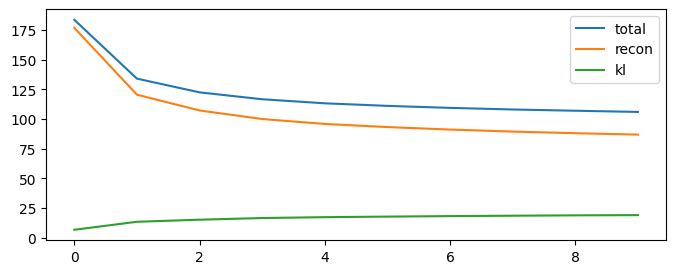

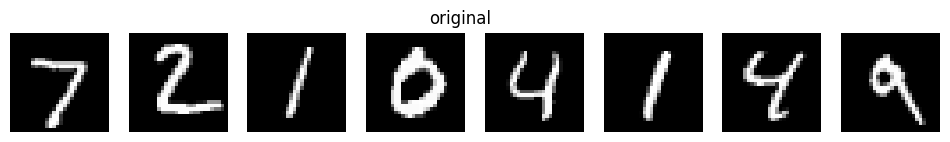

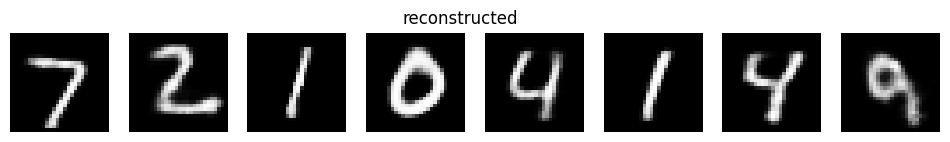

In [23]:
def show_images(imgs, title = ''):
    imgs = imgs.detach().cpu()
    fig, axes = plt.subplots(1, len(imgs), figsize = (len(imgs) * 1.5, 1.5))
    # 创建画布：1 行、N 列子图，N 等于图片数量；每张图片宽度固定 1.5 英寸，高度 1.5 英寸
    
    for ax, img in zip(axes, imgs):
        ax.imshow(img.view(28, 28), cmap = 'gray')
        ax.axis('off')      # 隐藏坐标轴，画面干净
    plt.suptitle(title)   # 给整行图片添加总标题
    plt.show()
# loss 曲线
plt.figure(figsize = (8, 3))
plt.plot(train_losses, label = 'total')
plt.plot(recon_losses, label = 'recon')
plt.plot(kl_losses, label = 'kl')
plt.legend()
plt.show()
# 重构对比：测试集前 8 张
model.eval()   # 测试模式
with torch.no_grad():               # 上下文管理器，关闭梯度计算。前向传播不构建计算图，节省显存、提速
    x, _ = next(iter(test_loader))  # 取出测试集第一批，`_` 丢弃标签
    x = x[:8].to(device)            # 截取前 8 张图像送入 GPU；
    x_hat, *_ = model(x)            # `*_`：忽略后面多余返回值 mu, logvar, z，只接收重建结果 x_hat
show_images(x, title = 'original')  # 画出原图
show_images(x_hat, title = 'reconstructed')    # 画出模型重建出来的图像

要点：eval() + no_grad() 两个都要——eval 关掉 BN/Dropout 的训练行为（本模型没有，但这是肌肉记忆），no_grad 不建计算图、省内存。
原图：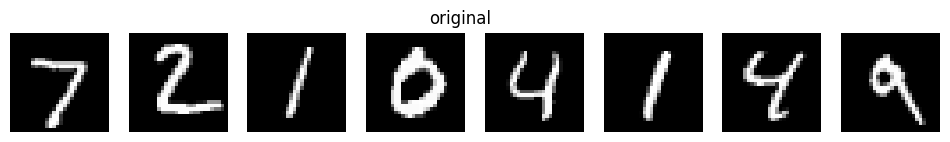
重构图：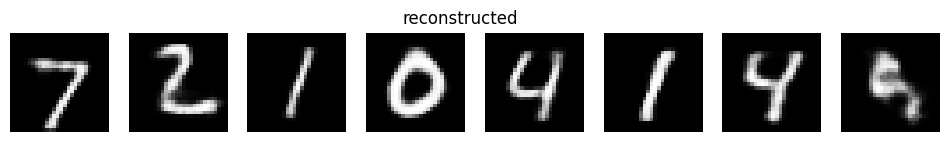

imgs = imgs.detach().cpu()
- `.detach()`：把张量**从计算图剥离**，不再追踪梯度。画图不需要反向传播，不 detach 有时会爆出显存警告。
- `.cpu()`：如果图像原先在 GPU 上，必须搬回 CPU，matplotlib 不能直接渲染 cuda 张量。

训练正常趋势参考：
1. recon 曲线持续下降，慢慢趋于平稳
2. KL 前期上升，latent_dim=20 时，最终稳定在≈20 附近
3. KL 过早跌到 0 → **后验塌陷 (posterior collapse)**，重建模糊

## 8.可视化 ②：latent 空间（验收项的硬证据）

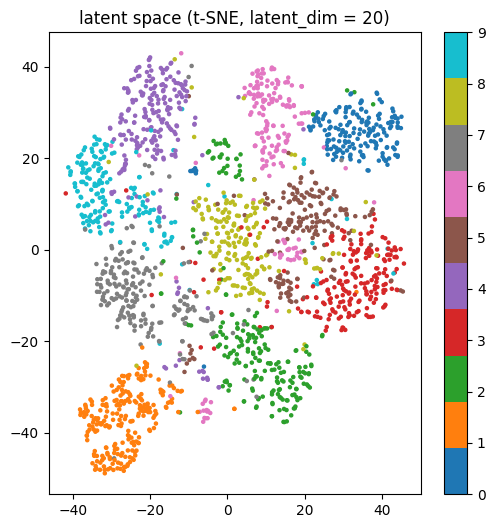

In [29]:
from sklearn.manifold import TSNE   # 导入 t‑SNE 降维工具
model.eval()
with torch.no_grad():
    zs, ys = [], []   # 空列表，分别用来分批存每一批图片的 mu 向量 (20 维)和每张图片对应的手写数字标签（0~9）
    for x, y in test_loader:
        x = x.to(device)        # 送入图片，运行 VAE 前向传播；返回值 (x_hat, mu, logvar, z)
        _, mu, _, _ = model(x)  # 只取出 mu，剩下三个值扔掉：确定性输出，点更稳
        zs.append(mu.cpu())     # 把这批样本的 mu 向量从GPU 上的数据搬到 CPU 内存再追加进列表 zs
        ys.append(y)            # 标签追加进 ys
    Z = torch.cat(zs).numpy()
    Y = torch.cat(ys).numpy()
Z2 = TSNE(n_components = 2, random_state = 42).fit_transform(Z[:2000])  
plt.figure(figsize = (6, 6))
plt.scatter(Z2[:, 0], Z2[:, 1], c= Y[:2000], cmap = 'tab10', s = 5)
plt.colorbar()    # 画出右边的色条图例
plt.title('latent space (t-SNE, latent_dim = 20)')
plt.show()

要点：<br>
用 mu 而不是 z 做可视化：mu 是 encoder 的确定性输出，采样 z 每次不一样，画出来是糊的；<br>
TSNE 只取 2000 点：全量 10000 点要跑几分钟，2000 点足够看出分簇结构；<br>
看图标准：10 个数字的颜色应该大致聚成团。分簇清晰 → VAE 学到了有意义的表示；糊成一团 → 模型没学好（latent 维度太多/epoch 不够）。<br>
想复刻 Kingma 论文里的经典 2D 图：把 LATENT_DIM 改成 2，重训一遍，然后 plt.scatter(mu[:,0], mu[:,1], c=y) 直接画，不用 TSNE。推荐两个都做，2D 版本最直观。

t‑SNE：**高维数据可视化算法**。当前的隐变量 $\boldsymbol \mu$ 是 20 维，无法直接画散点图；t‑SNE 将 20 维向量映射到**二维平面**，用来观察 VAE 隐空间的聚类结构。

Z = torch.cat(zs).numpy()
`zs` 是一堆分批的张量，`torch.cat`把它们拼在一起变成一个大矩阵：
- Z 的形状：`(10000, 20)`
- 10000 = MNIST 测试集全部样本数量；20 = 隐变量维度
- 一个测试图片对应的 20 维 mu 向量

Y = torch.cat(ys).numpy()
- Y 形状：`(10000,)`，里面存储每张图片的真实数字标签，0‑9

Z2 = TSNE(n_components = 2, random_state = 42).fit_transform(Z[:2000])
- `Z[:2000]`：只拿前 2000 张图片，10000 张 t‑SNE 运算速度会极慢。
- `n_components=2`：降成二维坐标，每个样本输出 (x,y)
- `random_state=42`：固定随机种子，每次运行 t‑SNE 得到一模一样的图，方便对比。
- Z2 形状：`(2000, 2)`，2000 个点，每个点一对 (x,y) 坐标！

`fit_transform()` = fit + transform
TSNE.fit(Z[:2000])        # 先学习数据
Z2 = TSNE.transform(Z[:2000]) # 再转换

plt.scatter(Z2[:, 0], Z2[:, 1], c= Y[:2000], cmap = 'tab10', s = 5)
- `Z2[:, 0]`：所有点的横坐标
- `Z2[:, 1]`：所有点的纵坐标
- `c=Y[:2000]`：**点的颜色 = 图片真实数字标签**
  - 标签 0 →蓝色
  - 标签 1 →橙色
  - 标签 2 →绿色
  - …… 一直到标签 9
- `cmap='tab10'`：正好 10 种不同颜色，对应 0‑9 十个数字
- `s=5`：每个圆点的大小

## 9.生成新样本（VAE 作为生成模型的证明）

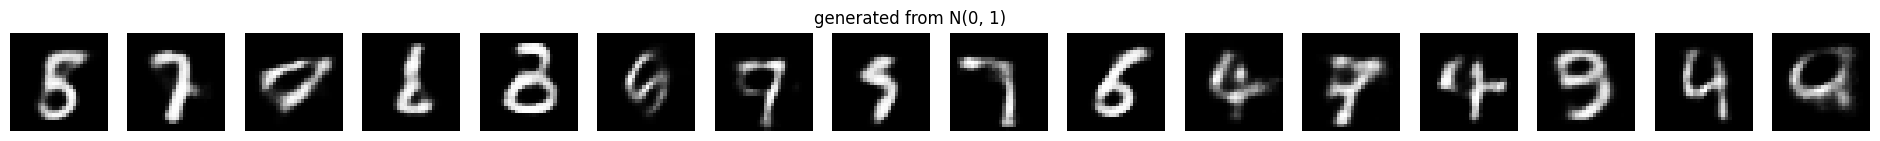

In [30]:
model.eval()
with torch.no_grad():
    z = torch.randn(16, LATENT_DIM, device = device)
    gen = model.decoder(z)   # 把 16 个随机隐向量送入解码器，生成图像
show_images(gen, title = 'generated from N(0, 1)')
torch.save(model.state_dict(), 'vae_mnist.pt')   # checkpoint，养成习惯

要点：生成 = 直接从先验 N(0,I) 采 z 过 decoder。这是 VAE 和普通 AE 的本质区别——AE 没有先验，无法从随机噪声生成新样本。生成的数字会偏模糊——正常，这是"独立像素 + 高斯假设"的代价，也是后面学 GAN/Diffusion 的动机钩子。这行 torch.save 顺手把 checkpoint 练了

z = torch.randn(16, LATENT_DIM, device = device)
从标准正态分布 (0, 1)采样; 16 行，每行是一个 20 维、服从 N (0,1) 的隐坐标点。

**为什么这里可以直接 randn 采样**？
- 训练阶段 KL 正则项一直在约束编码器输出的后验分布靠近 N(0,1)。
- 于是解码器学会了：**只要输入一个来自 N (0,1) 的 z，就输出一张手写数字图像**。

注意区分两个完全不一样的 z：
1. **训练阶段重参数得到的 z**：$z=\mu+\epsilon\cdot\sigma$，来自图片 x 对应的后验分布 $q(z|x)$
2. **生成阶段 randn 得到的 z**：直接采样先验分布 $p(z)=\mathcal{N}(0,1)$，**不需要原图 x**，从零创造新图片

数据流：<br>
$z:(16,20)\xrightarrow{\text{Decoder}} gen:(16,784)$ <br>
`gen`就是生成好、展平成 784 维的图像张量，值域在 (0,1)，正好适配`show_images`绘图函数。<br>
这里没有经过编码器！生成图片完全不需要编码器参与。VAE 生成 = 只用解码器。

`model.state_dict()`是什么？ <br>
`state_dict()`是一个**Python 字典**。 <br>
里面只保存网络**所有可训练参数（权重 weight、偏置 bias）**：编码器、解码器每一层的权重。 <br>
**不保存优化器、损失、epoch 等训练进度**

# 四、测试小结

1.进行 m=500 组实验，每组抽取 n=10 个样本。改变 m 和 n，观察和分析实验结果。<br>
实验对象：掷一个公平骰子（6 个面，每面真实概率 1/6 ≈ 0.167）。用代码模拟掷骰子：<br>
multinomial.Multinomial(n, fair_probs) 一次抽取 n 次，返回长度为 6 的计数向量。<br>
m 和 n 的含义：<br>
n = 每组实验的掷骰子次数（一次抽多少个样本）；<br>
m = 实验组数（抽多少组）；<br>
把 m 组的计数逐组累加（cumsum），每累加一组就算一次"到目前为止的相对频率"→ 得到 6 条估计概率曲线。（这是代码实验题——在 notebook 里补一个 cell 写采样代码跑，别空想。这正是"大数定律：频率收敛到概率"的实证。）<br>

- n 固定、m 增大：曲线前期振幅大、后期振幅小，整体趋于 1/6；不单调（随机波动，波折递减不是细节放大）；m 每 ×10，最终偏差渐近 ÷√10≈3.2。
- m 固定、n 增大：起步就接近 1/6（每组携带的信息多），最终同样收敛——因为有效样本总量 N = m×n，n 翻倍 ≈ m 翻倍，后期殊途同归；区别只在早期瞬态和单步粒度。
- n=1：曲线呈阶梯状，大量时间停在 0（图 3 可见占比很高）——因为每次累加只 +1 或 +0，相对频率以 1/累计次数 的粒度跳变。
- 数值衡量：MSE = p(1−p)/N 精确成立；RMSE ~ 1/√N（斜率 -1/2）。
- 大数定律：独立重复试验的样本总数越大，事件出现的**频率就收敛到它的真实概率**。

2.给定两个概率为 P(A) 和 P(B) 的事件，计算 P(A∪B) 和 P(A∩B) 的上限和下限。（提示：维恩图（Venn 图）。想想 A、B 两个圈重叠程度不同时，并集和交集分别能取到什么范围。）
- P(A∩B)的上限就是 min(P(A), P(B)),下限为0;P(A∪B)的上限为min(1,P(A)+P(B)),下限为max(P(A), P(B))

3.假设我们有一系列随机变量，例如 A、B 和 C，其中 B 只依赖于 A，而 C 只依赖于 B，能简化联合概率 P(A, B, C) 吗？（提示：这是一个马尔可夫链——想想链式法则 + 条件独立，最后能化简成几个因子的乘积。）
- $\boldsymbol{P(A,B,C) = P(A)\, P(B\,|\,A)\, P(C\,|\,B)}$

4.在 2.6.2.6 节（HIV 检测应用）中，第一个测试更准确。为什么不运行第一个测试两次，而是同时运行第一个和第二个测试？（答案藏在"条件独立"这个假设里——想想：如果跑同一个测试两次，两次结果给定 H 后还是独立的吗？）<br>
- 关键在条件独立假设：D₁、D₂ 是两个不同的检测方法，给定患病状态 H 后，它们的检测结果条件独立：P(D₁,D₂|H) = P(D₁|H)·P(D₂|H)。
- 为什么不跑同一个更准的测试两次：同一个测试跑两次，两次结果给定 H 后不独立——同一方法误差模式相同，结果强相关。条件独立假设在"同一测试重复两次"上不成立。假阳性率高的测试，H=0 时两次都阳性的概率不小（因为相关），第二次几乎不带来新信息。
- 为什么第二个测试有用：不同方法的误差互不相关，给定 H 后结果独立——两个不同测试同时阳性，在 H=0 条件下概率是乘积（极小），提供的是真正独立的新证据。所以书中后验从第一个测试阳性的 13% 提升到两个测试都阳性的 83%。

## 测试 1

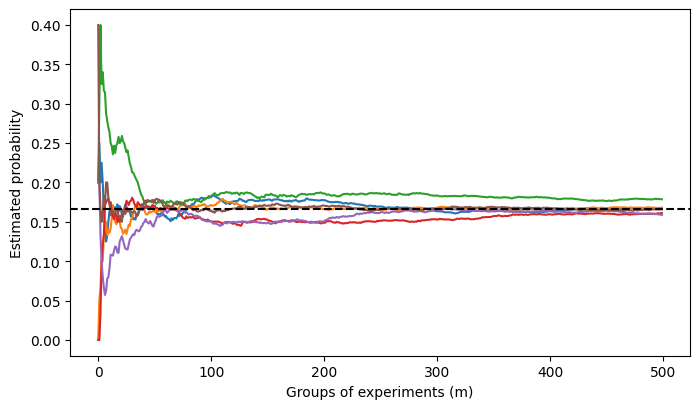

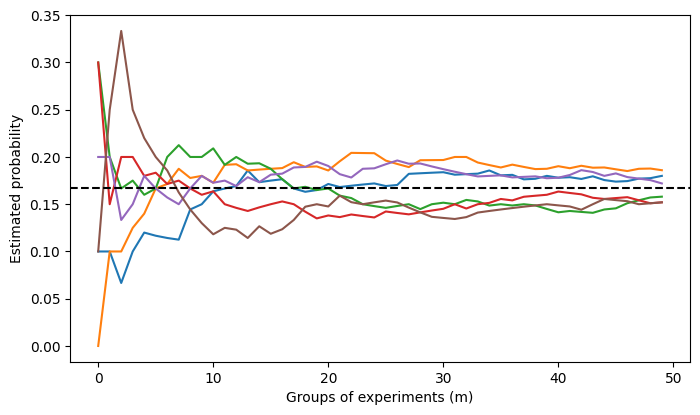

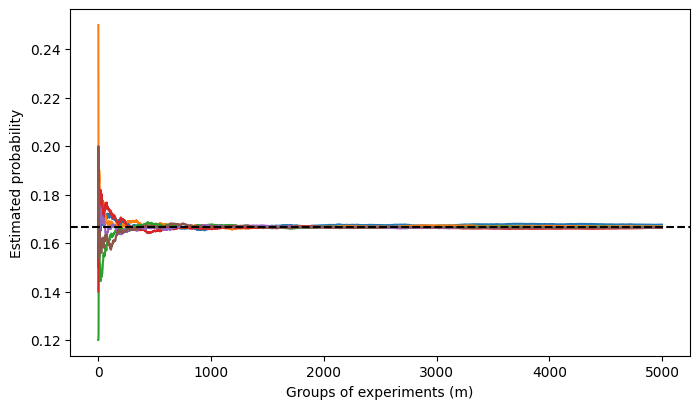

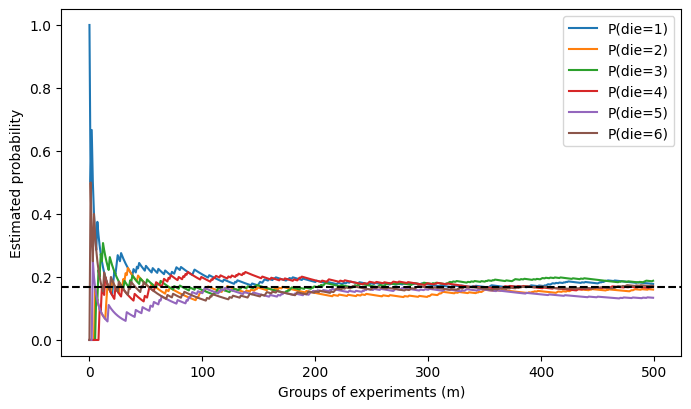

In [6]:
import torch
from torch.distributions import multinomial    # 导入库。multinomial 多项式分布：做 n 次独立试验，统计 6 个点数各自出现多少次。
import matplotlib.pyplot as plt
fair_probs = torch.ones(6) / 6   # 公平骰子,fair_probs = tensor([0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667])
# m=500 组，每组 n=10 次
counts = multinomial.Multinomial(10, fair_probs).sample((500,))    # counts.shape = torch.Size([500, 6])
cum_counts = counts.cumsum(dim=0)    # 沿着行方向做累加（累计求和）
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
plt.figure(figsize=(8, 4.5))
for i in range(6):
    plt.plot(estimates[:, i].numpy(), label=f"P(die={i+1})")
plt.axhline(y=1/6, color='black', linestyle='dashed')    # 黑色虚线 = 理论真实概率 1/6，作为收敛目标。
plt.xlabel('Groups of experiments (m)')
plt.ylabel('Estimated probability')

# m=50 组，每组 n=10 次
counts = multinomial.Multinomial(10, fair_probs).sample((50,))    # counts.shape = torch.Size([500, 6])
cum_counts = counts.cumsum(dim=0)    # 沿着行方向做累加（累计求和）
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
plt.figure(figsize=(8, 4.5))
for i in range(6):
    plt.plot(estimates[:, i].numpy(), label=f"P(die={i+1})")
plt.axhline(y=1/6, color='black', linestyle='dashed')    # 黑色虚线 = 理论真实概率 1/6，作为收敛目标。
plt.xlabel('Groups of experiments (m)')
plt.ylabel('Estimated probability')

# m=5000 组，每组 n=100 次
counts = multinomial.Multinomial(100, fair_probs).sample((5000,))    # counts.shape = torch.Size([500, 6])
cum_counts = counts.cumsum(dim=0)    # 沿着行方向做累加（累计求和）
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
plt.figure(figsize=(8, 4.5))
for i in range(6):
    plt.plot(estimates[:, i].numpy(), label=f"P(die={i+1})")
plt.axhline(y=1/6, color='black', linestyle='dashed')    # 黑色虚线 = 理论真实概率 1/6，作为收敛目标。
plt.xlabel('Groups of experiments (m)')
plt.ylabel('Estimated probability')

# m=500 组，每组 n=1 次
counts = multinomial.Multinomial(1, fair_probs).sample((500,))    # counts.shape = torch.Size([500, 6])
cum_counts = counts.cumsum(dim=0)    # 沿着行方向做累加（累计求和）
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
plt.figure(figsize=(8, 4.5))
for i in range(6):
    plt.plot(estimates[:, i].numpy(), label=f"P(die={i+1})")
plt.axhline(y=1/6, color='black', linestyle='dashed')    # 黑色虚线 = 理论真实概率 1/6，作为收敛目标。
plt.xlabel('Groups of experiments (m)')
plt.ylabel('Estimated probability')

plt.legend()
plt.show()

counts = multinomial.Multinomial(10, fair_probs).sample((500,))<br>
参数说明<br>
1. 第一个参数 `10` → n=10，**每组扔骰子 10 次**
2. `sample((500,))` → 采样 500 组，m=500
 **`counts.shape = torch.Size([500, 6])`**
- 行索引：第 0‑499 组，一共 500 组
- 每一行 `counts[k]`：一个长度为 6 的向量，表示**第 k 组 10 次投掷里，点数 1~6 分别出现了多少次**
- 一行所有数字相加永远等于 10：`counts[k].sum() = 10`
- 例子：一行 `[2, 1, 3, 0, 2, 2]` 代表：第 k 组扔 10 次，1 点出现 2 次、2 点 1 次、3 点 3 次……

cum_counts = counts.cumsum(dim=0)<br>
`cumsum(dim=0)`：**沿着行方向做累加（累计求和）** <br>
`cum_counts.shape = [500, 6]` <br>
举个例子：<br>
- `cum_counts[0]` = counts [0] →做完第 1 组后的总点数
- `cum_counts[1]` = counts [0] + counts [1] →做完前 2 组，20 次投掷累计结果
- `cum_counts[499]` = 500 组全部累加完成，总投掷次数 500 × 10 = 5000 次
> `cum_counts[i]`：做完前 i+1 组试验，6 个点数**累计出现总次数**

estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)<br>
1. `cum_counts.sum(dim=1, keepdims=True)` <br>
   - 按每一行求和，得到**累计投掷总次数**；`keepdims` 保留二维形状，保证广播除法正确
   - `estimates.shape = [500, 6]`
2. `estimates[i, j]`：做完前 i+1 组实验之后，点数 j+1 出现的**累计频率（概率估计值）**
也就是：<br>
$\text{estimates}[i,j]=\frac{\text{点数j累计出现次数}}{\text{到第i组为止，骰子总共投掷次数}}$

